In [33]:
import numpy as np
# import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import corner 
import scienceplots 
plt.style.use('science')

import os
import shutil

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"
print("PATH:", os.environ.get("PATH"))
print("pdflatex:", shutil.which("pdflatex"))

PATH: /Users/turtle/miniconda3/envs/bmc/bin:/Users/turtle/.local/bin:/Users/turtle/miniconda3/envs/bmc/bin:/Users/turtle/miniconda3/condabin:/usr/local/bin:/System/Cryptexes/App/usr/bin:/usr/bin:/bin:/usr/sbin:/sbin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/local/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/appleinternal/bin:/opt/pmk/env/global/bin:/Library/TeX/texbin:/Library/TeX/texbin:/Library/TeX/texbin:/Library/TeX/texbin:/Library/TeX/texbin
pdflatex: /Library/TeX/texbin/pdflatex


In [34]:
%reload_ext autoreload
%autoreload 2
from config import models, fy_added_models, colors_sets, alpha_train, alpha_test, alpha_validation, color_train, color_test, color_validation, size_train, size_test, size_validation, marker_train, marker_test, marker_validation
from data_loading import load_charge_radii, load_charge_radii_fy
from pre_processing import filtered_NZ_extraction, unified_NZ_extraction, selected_models_data_sets_extraction, models_output_extraction, filtered_models_output_extraction, filtered_models_output_dict_extraction, filtered_models_output_stable_extraction, isotope_chain_forward_differences
from splitting import new_split 
from plot import plot_singular_values, plot_model_predictions, plot_pc_rmse_curve, plot_bmc_error_heatmap_scatter, plot_filtered_supermodel, plot_filtered_supermodel_simplex, plot_coverage
from metrics import pc_rmse_curve, rndm_m_random_calculator, coverage
from samplers import gibbs_sampler
from prediction import build_bmc_error_dataframe, build_filtered_outputs_per_Z, BMCPredictor, build_bmc_intervals_per_Z

In [35]:
# Load experimental data
CR_experimental = load_charge_radii("../../data/charge_radii.csv")
bailey_data = load_charge_radii_fy("../../data/nuclei_min_energies_2.csv", output_col='Fy_Dr')
Fy_IVP = load_charge_radii_fy("../../data/fyivp_nuclei_min_energies.csv", output_col='Fy_IVP')

models_data_sets = {}
for model in models:
    Data_Values = pd.read_hdf("../../data/selected_data.h5", key = model)
    models_data_sets[model] = {"N" : Data_Values["N"], "Z" : Data_Values["Z"], "BE" : Data_Values["BE"], 'ChRad': Data_Values['ChRad']}
filtered_NZ = np.array([models_data_sets[models[0]]['N'].tolist(), models_data_sets[models[0]]['Z'].tolist() ]).T
stable_coordinates_full=np.loadtxt("../../Stable-Isotopes.txt")
stable_coordinates = filtered_NZ_extraction(stable_coordinates_full) # Make sure that nuclei we analyze have proton and neutron number of 8 or above
filtered_NZ = filtered_NZ_extraction(filtered_NZ) # This one will choose even-even isotope with N,Z >= 8
filtered_NZ, filtered_NZ_df = unified_NZ_extraction(models_data_sets, models, filtered_NZ)

In [36]:
selected_models_data_sets_radius = selected_models_data_sets_extraction(models_data_sets, models, filtered_NZ_df, 'ChRad')
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, bailey_data[['N', 'Z',  'Fy_Dr']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, Fy_IVP[['N', 'Z',  'Fy_IVP']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, CR_experimental[['N', 'Z',  'radius_val']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius.rename(columns = {'radius_val' : 'truth'}, inplace = True)
cols_radius = list(selected_models_data_sets_radius.keys())
# The next 2 lines help you to transition the truth column to the start of the dataframe
cols_radius.remove('truth')
cols_radius.insert(2, 'truth')
selected_models_data_sets_radius = selected_models_data_sets_radius[cols_radius]
selected_models_data_sets_radius = selected_models_data_sets_radius.copy().dropna().reset_index(drop = True)

filtered_NZ_df_radius = selected_models_data_sets_radius[['N', 'Z']]
filtered_NZ_radius = np.array(filtered_NZ_df_radius)
Full_set_radius = filtered_NZ_radius.copy()

stable_coordinates_df = pd.DataFrame({'N' : stable_coordinates.T[0], 'Z' : stable_coordinates.T[1]})
stable_coordinates_radius_df = pd.merge(filtered_NZ_df_radius, stable_coordinates_df, how = 'inner')
stable_coordinates_radius = stable_coordinates_radius_df.values

selected_models_data_sets_radius

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1,Fy_Dr,Fy_IVP
0,8,8,2.6991,2.729,2.691,2.747,2.735,2.794203,2.824011,2.795792,2.817382,2.793546,2.790816,2.753890,2.774552
1,10,8,2.7726,2.733,2.704,2.749,2.728,2.793734,2.825080,2.799074,2.807857,2.785015,2.781329,2.828447,2.835790
2,8,10,2.9714,2.956,2.912,2.945,2.955,2.956188,2.987489,2.964309,2.991813,2.966094,2.973445,2.993670,2.951307
3,10,10,3.0055,2.986,2.942,2.975,2.973,2.942506,2.973045,2.951974,2.974810,2.935663,2.967315,3.019625,3.000327
4,12,10,2.9525,2.960,2.949,2.978,2.941,2.964141,2.972133,2.976913,2.981346,2.925008,2.968485,3.028387,3.001396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,150,94,5.8948,5.933,5.920,5.930,5.942,5.910061,5.918577,5.915247,5.902641,5.908618,5.923415,5.915108,5.903815
341,146,96,5.8285,5.935,5.921,5.933,5.936,5.919476,5.928108,5.924384,5.908823,5.911968,5.928126,5.911279,5.902992
342,148,96,5.8429,5.948,5.938,5.947,5.951,5.929864,5.939063,5.934703,5.920200,5.923912,5.940104,5.924613,5.915440
343,150,96,5.8562,5.958,5.945,5.956,5.964,5.939141,5.949234,5.944656,5.930929,5.935161,5.951470,5.938320,5.927410


In [37]:
selected_models_data_sets_radius_trial = isotope_chain_forward_differences(selected_models_data_sets_radius, keep_prev_labels= False)
selected_models_data_sets_radius_trial

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1,Fy_Dr,Fy_IVP
0,10,8,0.0735,0.004,0.013,0.002,-0.007,-0.000469,0.001069,0.003282,-0.009525,-0.008531,-0.009487,0.074557,0.061238
1,10,10,0.0341,0.030,0.030,0.030,0.018,-0.013682,-0.014444,-0.012335,-0.017003,-0.030431,-0.006130,0.025955,0.049020
2,12,10,-0.0530,-0.026,0.007,0.003,-0.032,0.021635,-0.000912,0.024939,0.006536,-0.010655,0.001170,0.008762,0.001069
3,14,10,-0.0518,-0.042,-0.015,-0.030,-0.034,-0.019736,0.006621,-0.017525,-0.028468,0.003855,-0.031298,0.011240,-0.001311
4,16,10,0.0244,0.009,0.006,-0.013,-0.007,0.019412,0.018319,0.018502,0.018290,0.020975,0.014049,0.007797,-0.011783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,148,94,0.0122,0.016,0.018,0.016,0.017,0.009445,0.010642,0.009930,0.011258,0.012063,0.012125,0.015124,0.013333
293,150,94,0.0125,0.011,0.008,0.010,0.014,0.007853,0.009476,0.009450,0.010440,0.011359,0.011476,0.015188,0.013045
294,148,96,0.0144,0.013,0.017,0.014,0.015,0.010388,0.010955,0.010319,0.011377,0.011944,0.011978,0.013334,0.012448
295,150,96,0.0133,0.010,0.007,0.009,0.013,0.009277,0.010171,0.009953,0.010729,0.011249,0.011366,0.013707,0.011970


In [38]:
models = fy_added_models.copy()
models

['ME2',
 'MEdelta',
 'PC1',
 'NL3S',
 'SKMS',
 'SKP',
 'SLY4',
 'SV',
 'UNEDF0',
 'UNEDF1',
 'Fy_IVP',
 'Fy_Dr']

In [39]:
train_coordinates_radius, val_coordinates_radius, test_coordinates_radius = new_split(selected_models_data_sets_radius_trial)
train_set_radius = selected_models_data_sets_radius_trial[['N', 'Z']].iloc[train_coordinates_radius].values
val_set_radius = selected_models_data_sets_radius_trial[['N', 'Z']].iloc[val_coordinates_radius].values
test_set_radius = selected_models_data_sets_radius_trial[['N', 'Z']].iloc[test_coordinates_radius].values

selected_models_data_sets_radius = selected_models_data_sets_radius_trial.copy() 
"""
We will also have to find a new set of NZ that we are working with
"""
filtered_NZ_df = selected_models_data_sets_radius[['N', 'Z']]
filtered_NZ = filtered_NZ_df.values
filtered_NZ_df_radius = filtered_NZ_df.copy()
filtered_NZ_radius = filtered_NZ_df_radius.values

# We will now redefine what stable_coordinates_radius 
stable_coordinates_radius_df = pd.merge(filtered_NZ_df_radius, stable_coordinates_df, how = 'inner')

models_output_radius_list = models_output_extraction(selected_models_data_sets_radius, train_coordinates_radius, val_coordinates_radius, test_coordinates_radius)
[models_output_radius, models_output_radius_train, models_output_radius_validation, models_output_radius_test] = models_output_radius_list

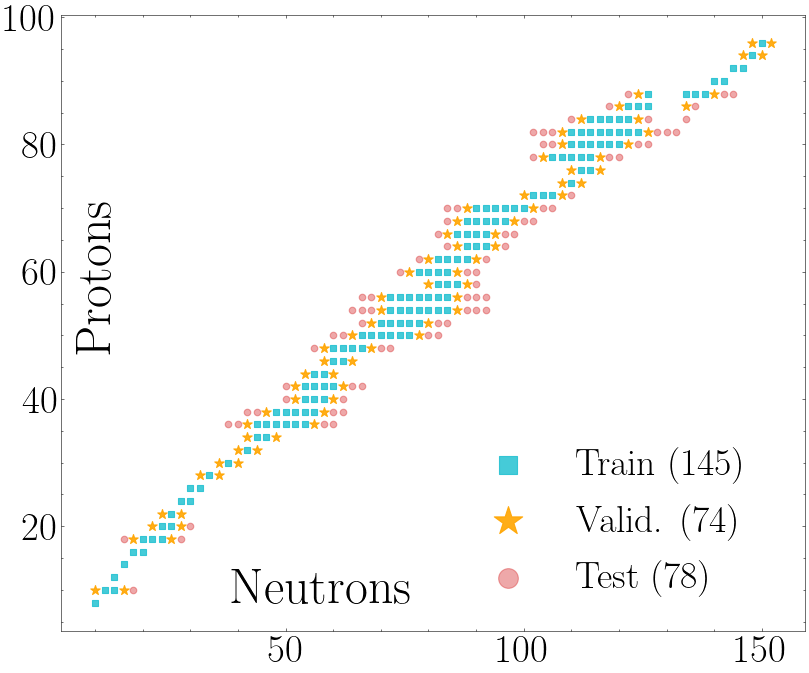

In [ ]:
train_coordinates_radius, val_coordinates_radius, test_coordinates_radius = new_split(selected_models_data_sets_radius)
train_set_radius = selected_models_data_sets_radius[['N', 'Z']].iloc[train_coordinates_radius].values
val_set_radius = selected_models_data_sets_radius[['N', 'Z']].iloc[val_coordinates_radius].values
test_set_radius = selected_models_data_sets_radius[['N', 'Z']].iloc[test_coordinates_radius].values

plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(12,10), dpi=80)

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

ax.scatter(x = train_set_radius.T[0], y = train_set_radius.T[1], label = "Train ("+ str(len(train_set_radius))+")", alpha = alpha_train,color=color_train,s=size_train,marker=marker_train)

ax.scatter(x = val_set_radius.T[0], y = val_set_radius.T[1], label = "Valid. (" + str(len(val_set_radius))+")", alpha = alpha_validation,color=color_validation,s=size_validation,marker=marker_validation)

ax.scatter(x = test_set_radius.T[0], y = test_set_radius.T[1], label = "Test (" + str(len(test_set_radius))+")", alpha = alpha_test,color=color_test,s=size_test,marker=marker_test)

# ax.scatter(x = stable_coordinates_radius.T[0], y = stable_coordinates_radius.T[1], label = "Stable", alpha = 0.8,color='black',s=11,marker="s")





# ax.scatter(x = np.array(AME2020New).T[0], y = np.array(AME2020New).T[1], label = "Valid. (" + str(len(validation_set))+")", alpha = alpha_validation,color=color_validation,s=size_validation,marker=marker_validation)


plt.xlabel('')

plt.annotate('Neutrons', xy=(0.35, 0.1), xycoords='axes fraction',
             ha='center', va='top', fontsize=45) 

plt.ylabel('')

plt.annotate('Protons', xy=(0.05,0.7), xycoords='axes fraction',
             ha='center', va='top', fontsize=45,rotation =90) 


# plt.ylabel("Protons",fontsize=45)
plt.legend(fontsize=34,markerscale=3 ,loc =(0.53,0.03))
# plt.savefig('../pp_plots/charge_radii_difference/whole_nuclei_chart_new_split.png')

plt.show()

In [42]:
model_predictions_radius=models_output_radius[models].values
model_predictions_radius_train=models_output_radius_train[models].values
model_predictions_radius_validation=models_output_radius_validation[models].values
model_predictions_radius_test=models_output_radius_test[models].values
model_predictions_radius_list = [model_predictions_radius, model_predictions_radius_train, model_predictions_radius_validation, model_predictions_radius_test]

predictions_mean_radius= np.mean(model_predictions_radius, axis=1)
predictions_mean_radius_train= np.mean(model_predictions_radius_train, axis=1)
predictions_mean_radius_validation= np.mean(model_predictions_radius_validation, axis=1)
predictions_mean_radius_test= np.mean(model_predictions_radius_test, axis=1)

predictions_mean_radius_df = pd.DataFrame({'N' : filtered_NZ_radius.T[0], 'Z' : filtered_NZ_radius.T[1], 'PC_0' : predictions_mean_radius})

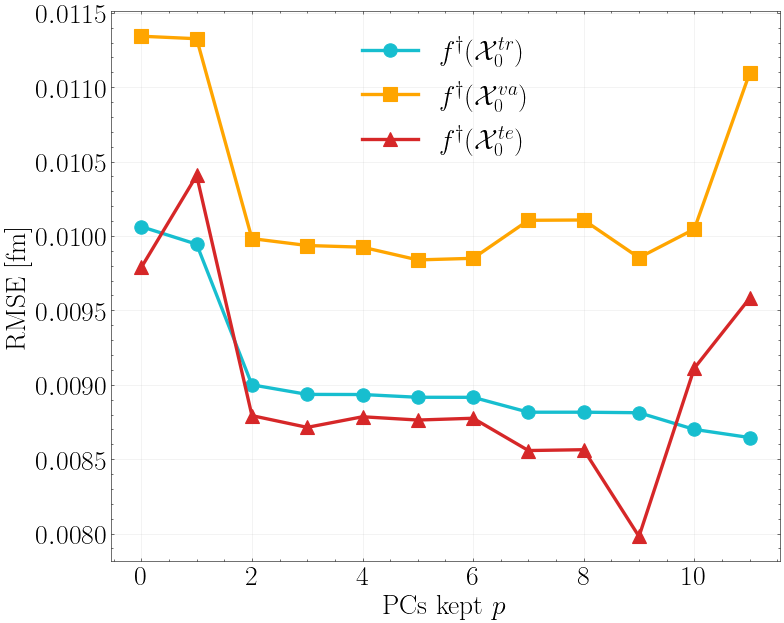

In [47]:
centering_data = True

if centering_data:
    model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,None]

U, S, Vt = np.linalg.svd(model_predictions_radius_train_processed)

rmse_df = pc_rmse_curve(
    train_df=models_output_radius_train,
    val_df=models_output_radius_validation,
    test_df=models_output_radius_test,
    full_df=models_output_radius,
    model_cols=models,
    Vt=Vt,
    truth_col='truth',
    max_components=len(models)-1
)
plot_pc_rmse_curve(
    rmse_df,
    title='', 
    dpi=80
)
plt.savefig('../pp_plots/charge_radii_difference/PC_RMSE_Curve.png')

In [49]:
components_kept = 9
U_hat = np.array([U.T[i] for i in range(components_kept)]).T
S_hat = S[:components_kept]
Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
Vt_hat_normalized=np.array([Vt[i] for i in range(components_kept)])

y_radius = models_output_radius_train['truth'] - predictions_mean_radius_train

X_train = U_hat.copy()
nu0_chosen=1
sigma20_chosen=0.01

samples = gibbs_sampler(y_radius, X_train, 50000,[np.full(components_kept,0),np.abs(np.diag(S[:components_kept]**2)), nu0_chosen, sigma20_chosen])

In [50]:
Z_values = sorted(models_output_radius['Z'].unique())
# 1) build filtered slices once
per_Z_radius = build_filtered_outputs_per_Z(
    models_output=models_output_radius,
    train_idx=train_coordinates_radius,
    val_idx=val_coordinates_radius,
    test_idx=test_coordinates_radius,
    stable_coordinates_df=stable_coordinates_radius_df,
    Z_values=Z_values,
    N_range=(0, 300)
)

# 2) build predictor once
predictor = BMCPredictor(samples=samples, Vt_hat=Vt_hat, n_draws=50000, seed=142858)

# 3) compute BMC intervals per Z
# IMPORTANT: model_cols must match the model order used when constructing Vt_hat  # or whatever ordering Vt_hat expects
bmc_per_Z = build_bmc_intervals_per_Z(per_Z_radius, predictor, models)


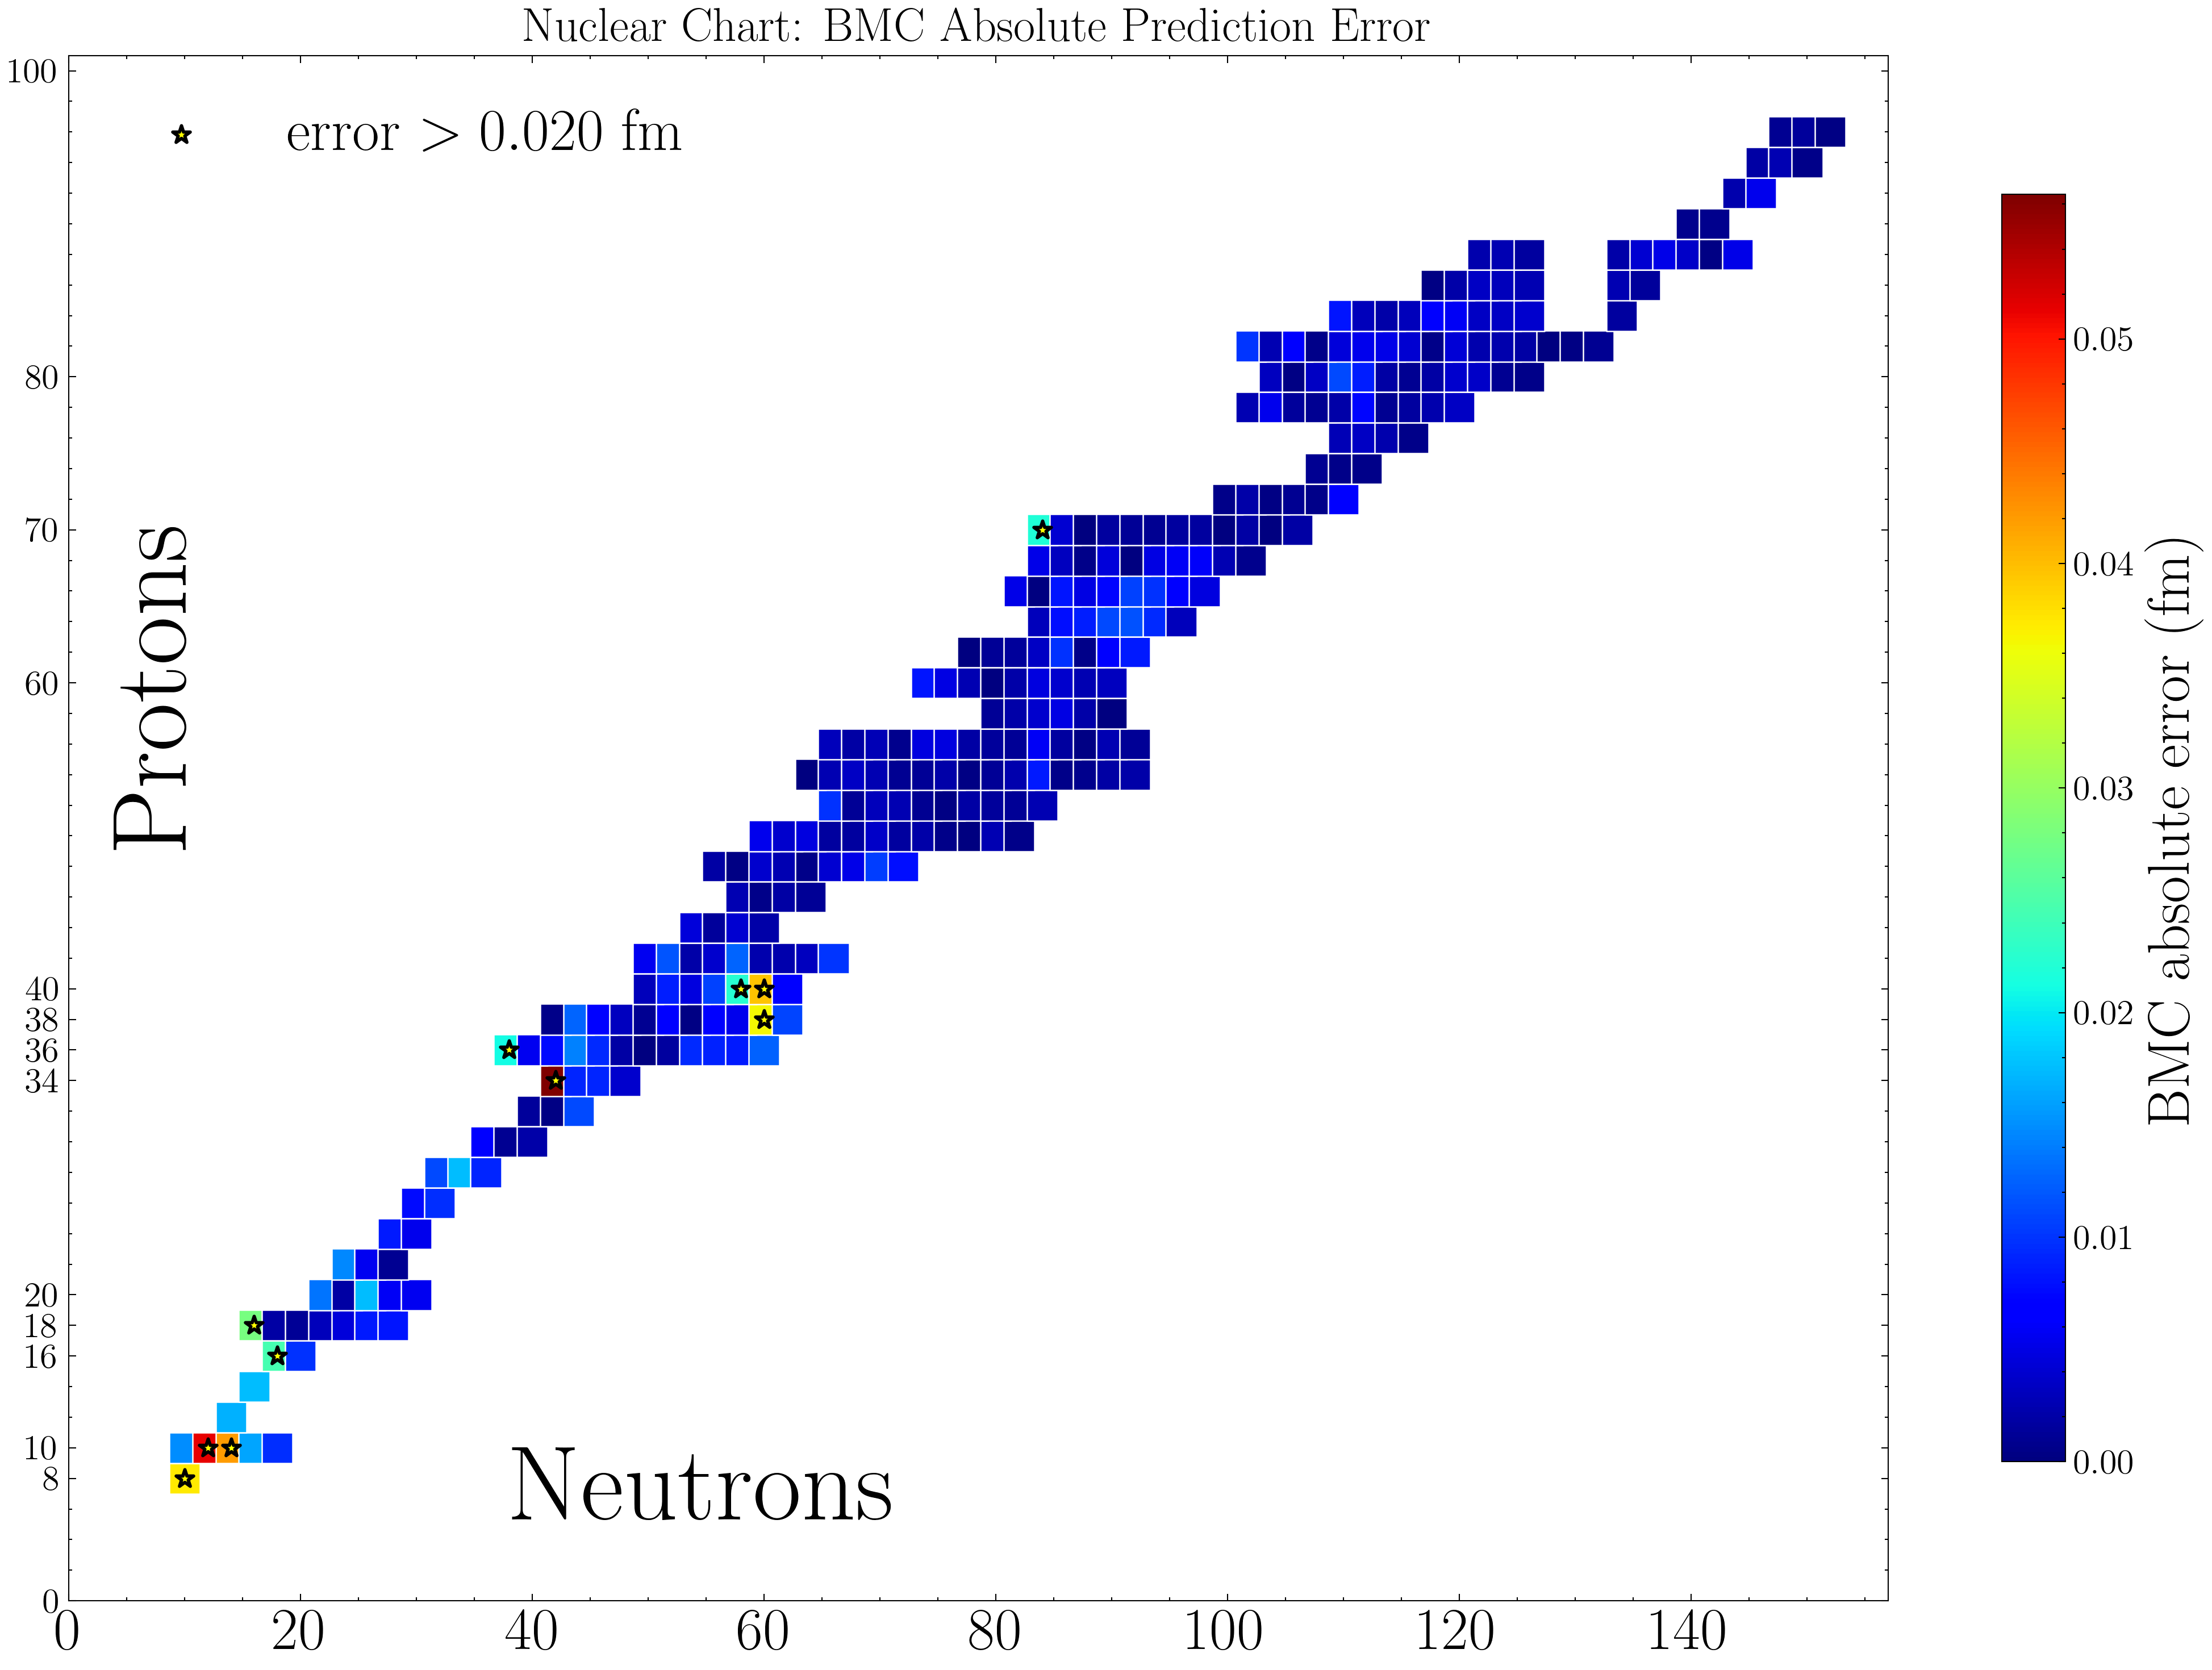

In [54]:
error_df = build_bmc_error_dataframe(per_Z_data=per_Z_radius, bmc_per_Z=bmc_per_Z, truth_col='truth')
plot_bmc_error_heatmap_scatter(error_df, threshold=0.02, cmap='jet', absolute_error=True)
plt.savefig('../pp_plots/charge_radii_difference/BMC_error_heatmap_absolute_metric.png')